In [1]:
import os
import zipfile
import shutil
import io
import pandas as pd
pd.set_option('display.max_columns', None)

### Mimic the POI data point extraction to find out how this was done for: https://arxiv.org/pdf/2506.00765

In [2]:
# from ohsome import OhsomeClient
# import pandas as pd, numpy as np, time, os, math, json
# from geopy.geocoders import Nominatim
# from geopy.extra.rate_limiter import RateLimiter
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from datetime import datetime
# from typing import Dict, Tuple, List

# # ---------- Config ----------
# ZIP_CODES = ["10002", "70302"]  # replace with your list
# YEAR_FROM, YEAR_TO = 2017, 2018
# BASE_URL = "https://api.ohsome.org/v1"   # or your local ohsome
# MAX_WORKERS = 8                          # be polite; 2–4 is usually safe
# SLEEP_BETWEEN_CALLS = 0.25               # seconds between API calls
# OUT_DIR = "poi_out"                      # per-ZIP outputs here

# POI_FILTERS = {
#     "bank":        "amenity=bank",
#     "bus":         "highway=bus_stop OR (public_transport=platform AND bus=yes)",
#     "hospital":    "amenity=hospital OR amenity=clinic",
#     "mall":        "shop=mall OR landuse=retail",
#     "park":        "leisure=park OR boundary=national_park OR landuse=grass",
#     "restaurant":  "amenity=restaurant OR amenity=fast_food OR amenity=cafe",
#     "school":      "amenity=school OR amenity=college OR amenity=university",
#     "station":     "railway=station OR public_transport=station",
#     "supermarket": "shop=supermarket OR amenity=marketplace",
# }

# os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
# def already_done(zip_code: str) -> bool:
#     return os.path.exists(os.path.join(OUT_DIR, f"{zip_code}_poi_counts_monthly.csv"))

# def process_zip(zip_code: str) -> Tuple[str, str]:
#     """
#     Worker: fetch, save per-ZIP CSV (raw). Returns (zip, status).
#     Per-ZIP write lets you resume without redoing finished ZIPs.
#     """
#     try:
#         if already_done(zip_code):
#             return (zip_code, "skipped (exists)")
#         df = collect_zip_monthly_pois(zip_code)
#         # Save per-ZIP raw (month index → column)
#         out = df.reset_index(names="month")
#         out.to_csv(os.path.join(OUT_DIR, f"{zip_code}_poi_counts_monthly.csv"), index=False)
#         return (zip_code, "ok")
#     except Exception as e:
#         return (zip_code, f"error: {e}")

# def build_poi_panel_parallel(zip_codes=ZIP_CODES, max_workers=MAX_WORKERS) -> Tuple[pd.DataFrame, pd.DataFrame]:
#     """
#     Runs ZIPs in parallel, then merges all per-ZIP CSVs, applies global imputation + log1p,
#     and writes panel CSVs.
#     """
#     # 1) Parallel per-ZIP fetch → impute-within → save
#     todo = [z for z in zip_codes if not already_done(z)]
#     if todo:
#         with ThreadPoolExecutor(max_workers=max_workers) as ex:
#             futures = {ex.submit(process_zip, z): z for z in todo}
#             for f in as_completed(futures):
#                 z = futures[f]
#                 status = f.result()
#                 print(status)

#     # 2) Merge all per-ZIP CSVs
#     frames = []
#     for z in zip_codes:
#         p = os.path.join(OUT_DIR, f"{z}_poi_counts_monthly.csv")
#         if not os.path.exists(p):
#             raise FileNotFoundError(f"Missing expected per-ZIP CSV for {z}: {p}")
#         frames.append(pd.read_csv(p, parse_dates=["month"]))
#     panel = pd.concat(frames, ignore_index=True).sort_values(["zip", "month"])

#     # 3) Global imputation + log
#     panel_log = log_transform(panel)

#     # 4) Save combined panels
#     panel.to_csv(os.path.join(OUT_DIR, "poi_counts_monthly_panel.csv"), index=False)
#     panel_log.to_csv(os.path.join(OUT_DIR, "poi_counts_monthly_panel_log.csv"), index=False)
#     return panel, panel_log


# # -------------------------------
# # UTILITIES
# # -------------------------------

# def geocode_zip_bbox(zip_code: str, country="USA", pause=1.0) -> List[float]:
#     """Nominatim → bbox as [minLon, minLat, maxLon, maxLat]. Cache results to avoid re-geocoding."""
#     cache_path = os.path.join(OUT_DIR, "bbox_cache.json")
#     cache = {}
#     if os.path.exists(cache_path):
#         try:
#             cache = json.load(open(cache_path, "r"))
#         except Exception:
#             cache = {}
#     if zip_code in cache:
#         return cache[zip_code]

#     geolocator = Nominatim(user_agent="poi-pipeline-ohsomepy", timeout=10)
#     rate = RateLimiter(geolocator.geocode, min_delay_seconds=pause, max_retries=3, error_wait_seconds=2)
#     loc = rate(f"{zip_code}, {country}", addressdetails=True, exactly_one=True)
#     if not loc or "boundingbox" not in getattr(loc, "raw", {}):
#         raise ValueError(f"Could not geocode ZIP: {zip_code}")
#     south, north, west, east = map(float, loc.raw["boundingbox"])
#     bbox = [west, south, east, north]
#     cache[zip_code] = bbox
#     with open(cache_path, "w") as f:
#         json.dump(cache, f)
#     return bbox

# def year_interval(y: int) -> str:
#     return f"{y}-01-01/{y}-12-31/P1M"  # monthly buckets

# def backoff_sleep(attempt: int):
#     # 0, 1, 2, 3, 4 → 0.5s, 1s, 2s, 4s, 8s (capped)
#     time.sleep(min(0.5 * (2 ** attempt), 8.0))

# def fetch_series_for_filter(client: OhsomeClient, bbox: List[float], filter_expr: str,
#                             year_from=YEAR_FROM, year_to=YEAR_TO,
#                             pause=SLEEP_BETWEEN_CALLS,
#                             max_retries=5) -> pd.Series:
#     """Hits /elements/count/series year-by-year; returns a monthly Series."""
#     pieces = []
#     for y in range(year_from, year_to + 1):
#         time_param = year_interval(y)
#         attempt = 0
#         while True:
#             try:
#                 resp = client.post(
#                     endpoint="elements/count/series",
#                     bboxes=bbox,      # [minLon, minLat, maxLon, maxLat]
#                     time=time_param,
#                     filter=filter_expr,
#                 )
#                 df = resp.as_dataframe()  # columns: timestamp, value
#                 s = pd.Series(
#                     df["value"].to_numpy(),
#                     index=pd.to_datetime(df["timestamp"]).tz_localize(None),
#                     dtype="float",
#                 ).asfreq("MS")
#                 pieces.append(s)
#                 time.sleep(pause)
#                 break
#             except Exception as e:
#                 if attempt >= max_retries:
#                     raise RuntimeError(f"Failed fetching {filter_expr} for {y}: {e}") from e
#                 backoff_sleep(attempt)
#                 attempt += 1
#                 continue
#     if not pieces:
#         return pd.Series(dtype="float")
#     out = pd.concat(pieces).sort_index()
#     return out[~out.index.duplicated(keep="first")]

# def collect_zip_monthly_pois(zip_code: str) -> pd.DataFrame:
#     """Collect all categories for one ZIP (with its own OhsomeClient)."""
#     bbox = geocode_zip_bbox(zip_code)
#     client = OhsomeClient(base_api_url=BASE_URL)  # new client per worker
#     cols = []
#     for cat, filt in POI_FILTERS.items():
#         s = fetch_series_for_filter(client, bbox, filt)
#         s.name = cat
#         cols.append(s)
#     df = pd.concat(cols, axis=1).sort_index()
#     df.insert(0, "zip", zip_code)
#     return df

# def log_transform(panel: pd.DataFrame) -> pd.DataFrame:
#     num_cols = [c for c in panel.columns if c not in ("month", "zip")]
#     out = panel.copy()
#     out[num_cols] = np.log1p(out[num_cols].astype(float))
#     return out

## Gather Zillow Data

In [4]:
!pwd

/Users/karanveer_lamba/Desktop/MIDS_CAPSTONE_PROJECT/RentIQ/EDA


In [5]:
# Pull in Zillow data
zillow_df = pd.read_csv("/Users/karanveer_lamba/Desktop/MIDS_CAPSTONE_PROJECT/RentIQ/EDA/Datasets/Zillow/zillow_rental_data.csv")

In [6]:
# Zillow data for NYC
zillow_ny = zillow_df[zillow_df['State']=='NY']

In [7]:
# Select relvevant columns
zillow_cols = ['RegionName', 'City', 'CountyName'] + list(zillow_ny.columns[33:117])
zillow_ny = zillow_ny[zillow_cols]

# Rename the zip column
zillow_ny = zillow_ny.rename(columns={"RegionName" : "zipcode"})

# Keep only non-null values from 2017-2023 (consistent with the range of HouseTS data)
zillow_ny = zillow_ny[zillow_ny['2017-01-31'].notna()].reset_index(drop=True)

In [8]:
# Convert wide data to long data
zillow_long = zillow_ny.melt(
    id_vars=["zipcode", "City", "CountyName"],      # Keep ZipCode fixed
    var_name="date",          # Column name for former date-columns
    value_name="median_rent"         # Column name for values
)

# Convert Date column to datetime type
zillow_long["date"] = pd.to_datetime(zillow_long["date"])

In [9]:
zillow_long = zillow_long.rename(columns={'City' : 'city',
                                          'CountyName' : 'county'})

In [10]:
# Create a list of NYC zip codes
zillow_zips = zillow_long['zipcode'].unique().tolist()

## Gather HouseTS Dataset

In [25]:
# Pull data HouseTS Dataset
house_data = pd.read_csv("/Users/karanveer_lamba/Desktop/MIDS_CAPSTONE_PROJECT/RentIQ/EDA/Datasets/HouseTS/HouseTS.csv")

In [26]:
# Look at the shape
house_data.shape

(884092, 39)

In [27]:
# What features are available
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884092 entries, 0 to 884091
Data columns (total 39 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   date                          884092 non-null  object 
 1   median_sale_price             884092 non-null  float64
 2   median_list_price             884092 non-null  float64
 3   median_ppsf                   884092 non-null  float64
 4   median_list_ppsf              884092 non-null  float64
 5   homes_sold                    884092 non-null  float64
 6   pending_sales                 884092 non-null  float64
 7   new_listings                  884092 non-null  float64
 8   inventory                     884092 non-null  float64
 9   median_dom                    884092 non-null  float64
 10  avg_sale_to_list              884092 non-null  float64
 11  sold_above_list               884092 non-null  float64
 12  off_market_in_two_weeks       884092 non-nul

In [28]:
# View dataframe head
house_data.head()

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full
0,2012-03-31,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,0.943662,0.142857,0.043478,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Alpharetta
1,2012-04-30,61870.0,245000.0,40.723982,130.528256,22.0,29.0,56.0,69.0,89.5,0.946642,0.090909,0.034483,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202421.064584,Atlanta-Sandy Springs-Alpharetta
2,2012-05-31,125500.0,217450.0,63.913043,119.919216,24.0,40.0,63.0,60.0,144.5,0.955624,0.208333,0.100000,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202681.309539,Atlanta-Sandy Springs-Alpharetta
3,2012-06-30,153000.0,189900.0,81.598080,105.617353,34.0,46.0,50.0,57.0,126.0,0.970608,0.176471,0.108696,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202998.603897,Atlanta-Sandy Springs-Alpharetta
4,2012-07-31,165500.0,154000.0,81.598080,83.921175,39.0,49.0,42.0,50.0,80.0,0.982105,0.256410,0.102041,ATL,30002,2012,12.0,2.0,3.0,1.0,60.0,45.0,57.0,4.0,6.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,203781.903446,Atlanta-Sandy Springs-Alpharetta


In [29]:
# Convert the date column to datetime object
house_data['date'] = pd.to_datetime(house_data['date'])

In [30]:
# Filter the TS data to records that exist in the Zillow dataset
house_data_nyc = house_data[house_data['city']=='NY']

In [31]:
# Filter the data to start from 2017
house_data_nyc = house_data_nyc[house_data_nyc['date'] >= pd.to_datetime('2017-01-01')].reset_index(drop=True)

In [32]:
# Retain only the zipcodes that are in the zillow rentals dataset
house_data_nyc = house_data_nyc[house_data_nyc['zipcode'].isin(zillow_zips)]

In [33]:
house_data_nyc.shape

(6300, 39)

In [35]:
zillow_long

,zipcode,city,county,date,median_rent
0,11385,New York,Queens County,2017-01-31,2303.742913
1,10467,New York,Bronx County,2017-01-31,1320.387659
2,11226,New York,Kings County,2017-01-31,2333.401703
3,11207,New York,Kings County,2017-01-31,2184.043420
4,10025,New York,New York County,2017-01-31,3184.747277
...,...,...,...,...,...
6547,10007,New York,New York County,2023-12-31,7362.615226
6548,10018,New York,New York County,2023-12-31,4392.677529
6549,10280,New York,New York County,2023-12-31,4535.575909
6550,11109,New York,Queens County,2023-12-31,4201.434278


In [36]:
house_data_nyc = house_data_nyc.merge(
    right=zillow_long,
    how='left',
    on=['zipcode', 'date'],
    suffixes=("_ts", "_zlw")
)

In [38]:
house_data_nyc.head()

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city_ts,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,city_zlw,county,median_rent
0,2017-01-31,1750000.0,4135000.0,1247.500000,2585.751979,17.0,17.0,86.0,252.0,161.0,0.978486,0.000000,0.000000,NY,10001,2017,258.0,8.0,56.0,10.0,515.0,1450.0,385.0,174.0,135.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.670502e+06,New York-Newark-Jersey City,New York,New York County,3922.292665
1,2017-02-28,2015000.0,4600000.0,1444.801541,2748.473071,12.0,12.0,89.0,264.0,132.0,0.979087,0.000000,0.000000,NY,10001,2017,259.0,8.0,56.0,10.0,511.0,1468.0,387.0,175.0,142.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.689583e+06,New York-Newark-Jersey City,New York,New York County,3863.891996
2,2017-03-31,1275000.0,3825000.0,1448.087432,2517.513135,15.0,12.0,99.0,276.0,141.0,0.984734,0.000000,0.000000,NY,10001,2017,259.0,9.0,56.0,10.0,510.0,1495.0,387.0,172.0,146.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.688465e+06,New York-Newark-Jersey City,New York,New York County,3873.435091
3,2017-04-30,1512500.0,2675000.0,1372.288623,2176.148047,14.0,13.0,67.0,264.0,165.0,0.996564,0.142857,0.076923,NY,10001,2017,260.0,9.0,54.0,12.0,508.0,1534.0,386.0,172.0,151.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.696703e+06,New York-Newark-Jersey City,New York,New York County,3891.172482
4,2017-05-31,1300000.0,2600000.0,1451.394082,1975.308642,27.0,25.0,65.0,251.0,166.5,0.984016,0.074074,0.040000,NY,10001,2017,265.0,9.0,54.0,12.0,508.0,1584.0,385.0,172.0,152.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.681455e+06,New York-Newark-Jersey City,New York,New York County,3957.284734


## Plot Variables to understand data point distribution and relationships

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [48]:
house_data_nyc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6300 entries, 0 to 6299
Data columns (total 42 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          6300 non-null   datetime64[ns]
 1   median_sale_price             6300 non-null   float64       
 2   median_list_price             6300 non-null   float64       
 3   median_ppsf                   6300 non-null   float64       
 4   median_list_ppsf              6300 non-null   float64       
 5   homes_sold                    6300 non-null   float64       
 6   pending_sales                 6300 non-null   float64       
 7   new_listings                  6300 non-null   float64       
 8   inventory                     6300 non-null   float64       
 9   median_dom                    6300 non-null   float64       
 10  avg_sale_to_list              6300 non-null   float64       
 11  sold_above_list               

/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and wil

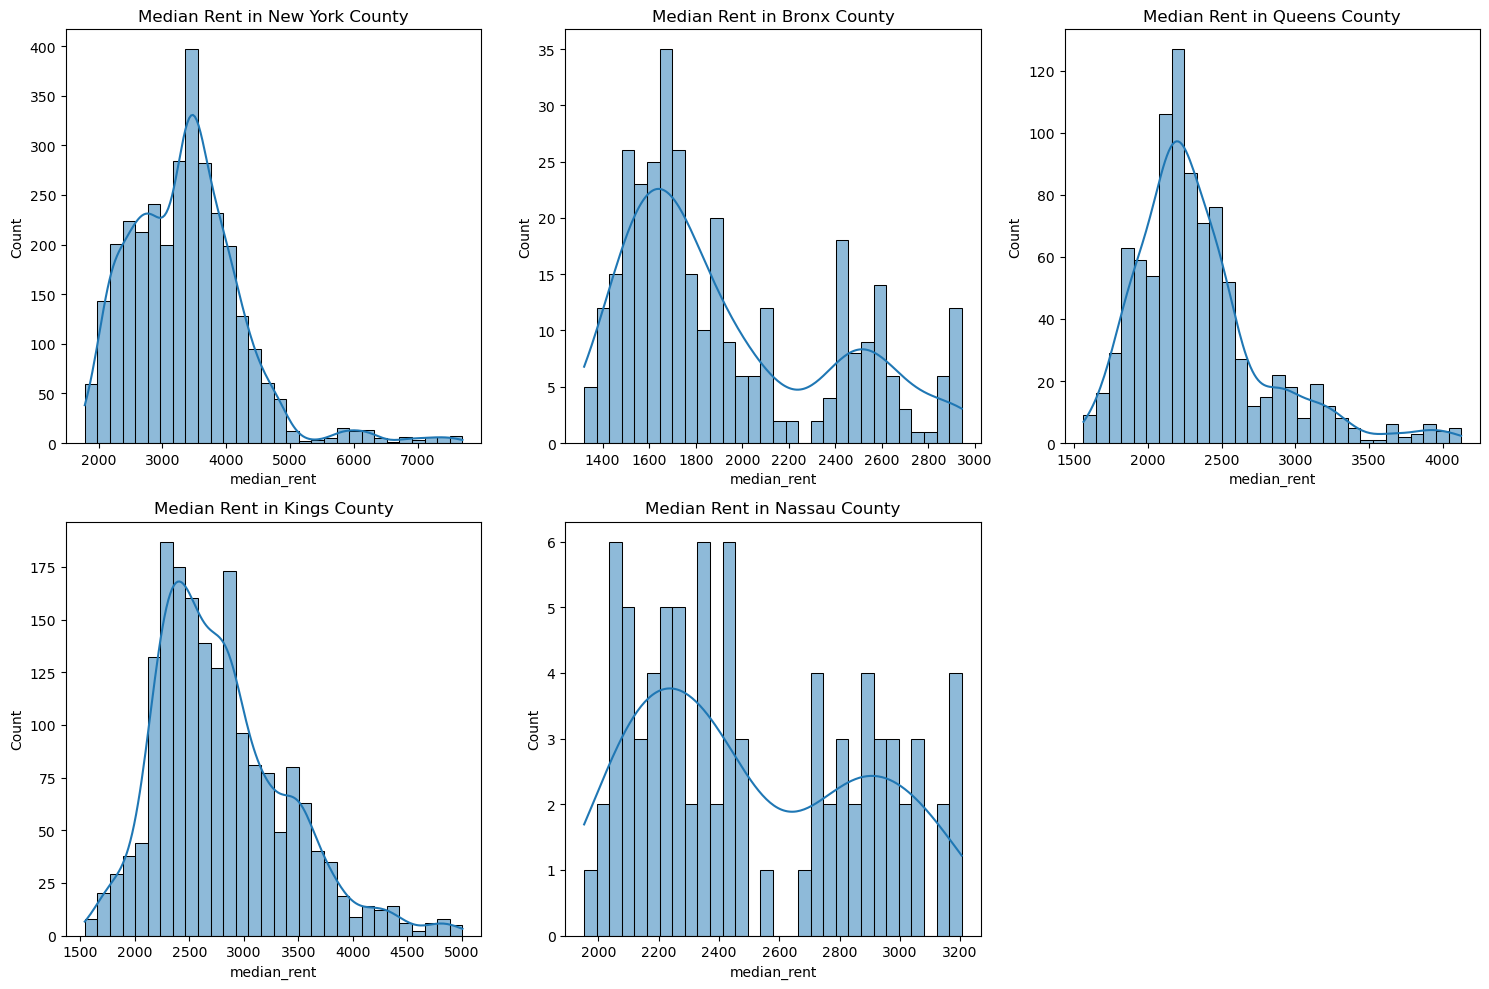

In [45]:
county_list = house_data_nyc['county'].unique().tolist()

# Decide number of rows and columns
n = len(county_list)
ncols = 3   # you can change depending on how many per row you want
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
axes = axes.flatten()  # flatten to 1D for easy indexing

for i, county in enumerate(county_list):
    ax = axes[i]
    sns.histplot(
        data=house_data_nyc[house_data_nyc['county'] == county],
        x="median_rent", bins=30, kde=True, ax=ax
    )
    ax.set_title(f"Median Rent in {county}")

# Hide any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

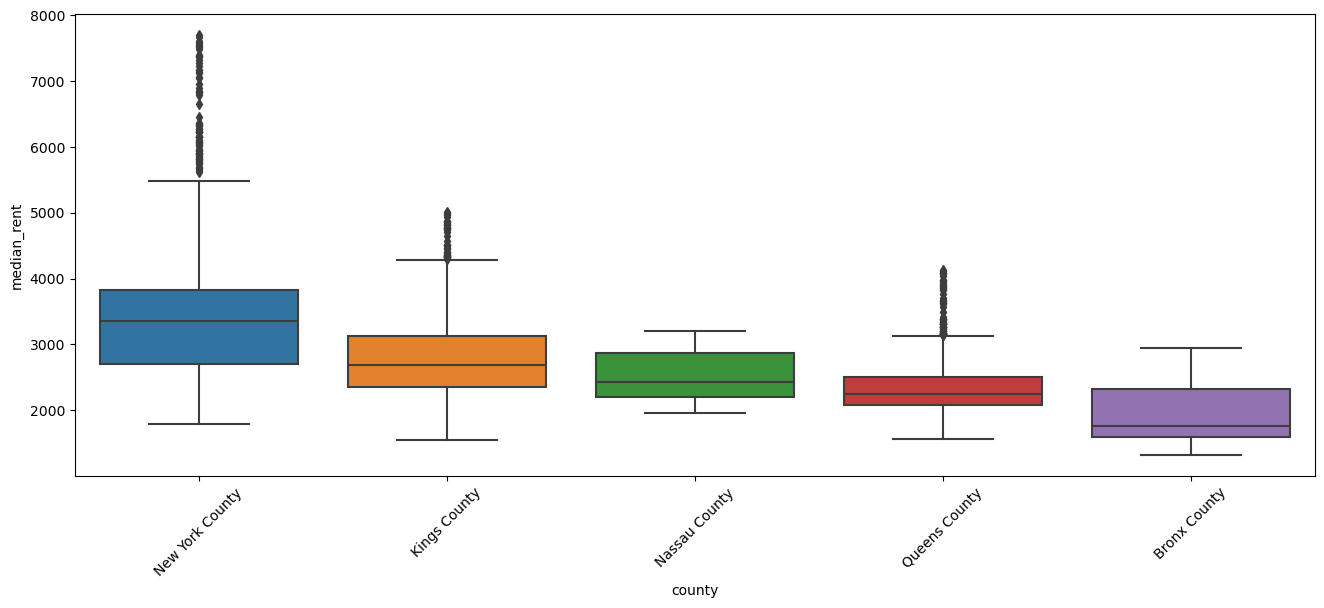

In [46]:
order = house_data_nyc.groupby("county")["median_rent"].median().sort_values(ascending=False).index
plt.figure(figsize=(16,6))
sns.boxplot(data=house_data_nyc, x="county", y="median_rent", order=order)
plt.xticks(rotation=45)
plt.show()

/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


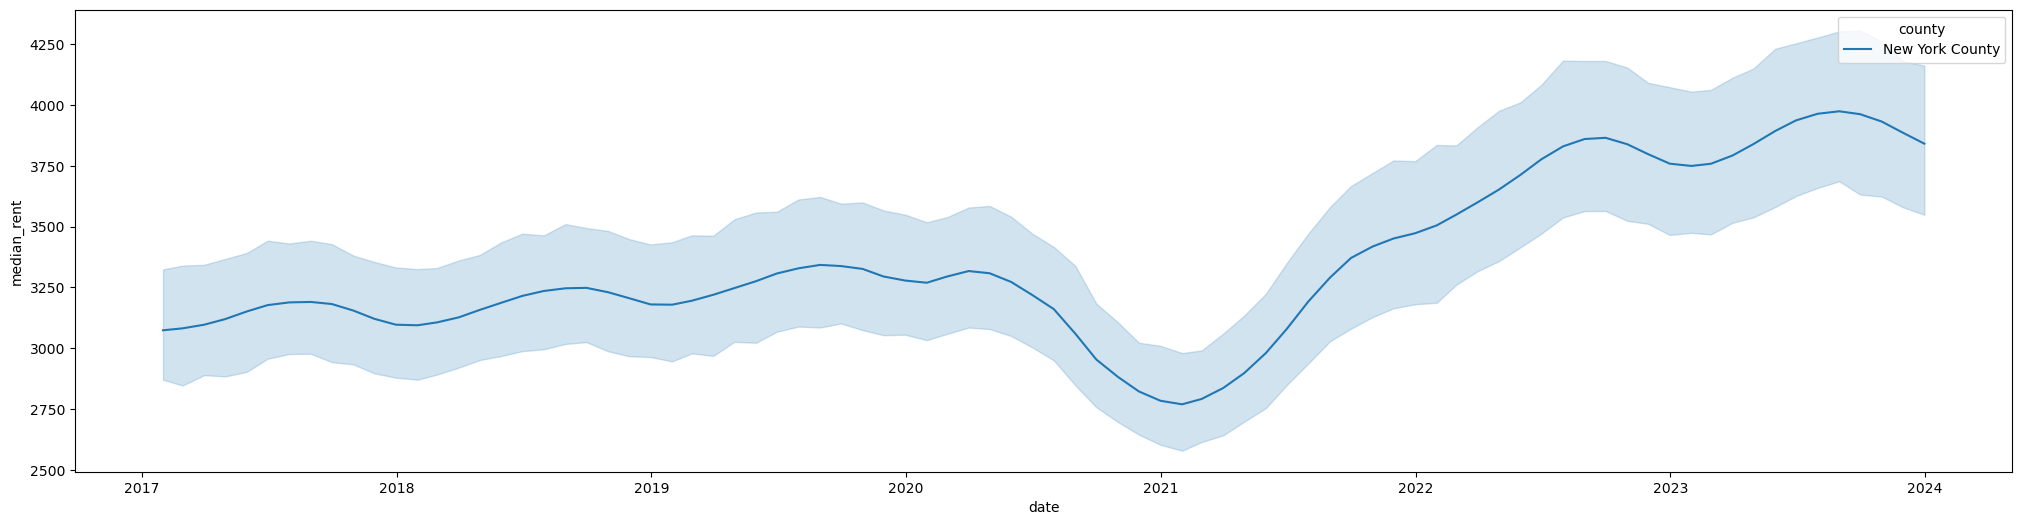

In [47]:
plt.figure(figsize=(25,6))
sns.lineplot(data=house_data_nyc[house_data_nyc['county']=="New York County"], x="date", y="median_rent", hue="county")
plt.show()

/Users/karanveer_lamba/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='median_rent', ylabel='Count'>

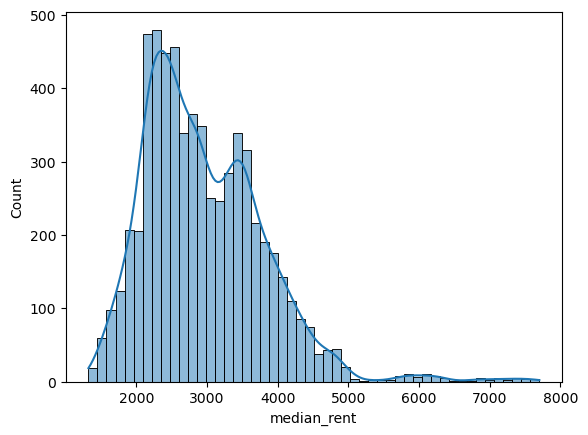

In [50]:
sns.histplot(house_data_nyc["median_rent"], bins=50, kde=True)

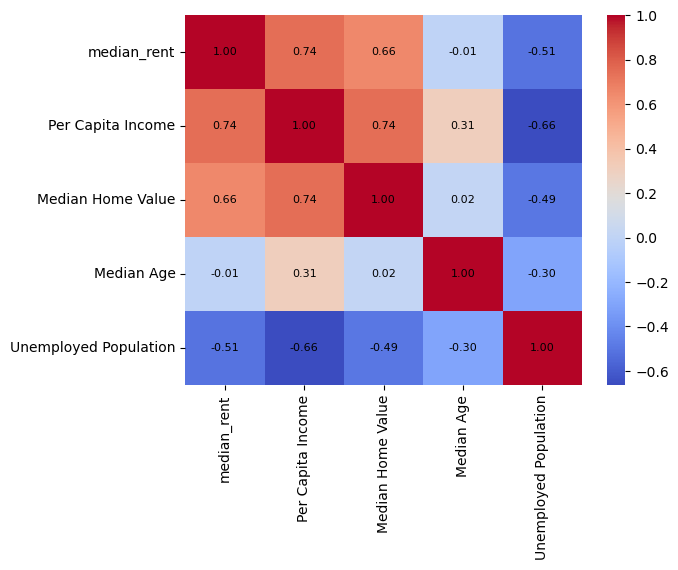

In [53]:
corr = house_data_nyc[["median_rent","Per Capita Income","Median Home Value","Median Age","Unemployed Population"]].corr()
ax = sns.heatmap(corr, annot=False, cmap="coolwarm")

# Manually add text
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j+0.5, i+0.5, f"{corr.iloc[i,j]:.2f}",
                ha="center", va="center", color="black", fontsize=8)

plt.show()

In [55]:
house_data_nyc.head(2)

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city_ts,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,city_zlw,county,median_rent
0,2017-01-31,1750000.0,4135000.0,1247.500000,2585.751979,17.0,17.0,86.0,252.0,161.0,0.978486,0.0,0.0,NY,10001,2017,258.0,8.0,56.0,10.0,515.0,1450.0,385.0,174.0,135.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.670502e+06,New York-Newark-Jersey City,New York,New York County,3922.292665
1,2017-02-28,2015000.0,4600000.0,1444.801541,2748.473071,12.0,12.0,89.0,264.0,132.0,0.979087,0.0,0.0,NY,10001,2017,259.0,8.0,56.0,10.0,511.0,1468.0,387.0,175.0,142.0,23332.0,35.8,86347.0,22359.0,13520.0,2114.0,460500.0,14899.0,1029.0,23003.0,23003.0,12853.0,2.689583e+06,New York-Newark-Jersey City,New York,New York County,3863.891996


In [58]:
# Create a new dataset with rent and POI variables
poi_dataset = house_data_nyc[['date', 'zipcode', 
                              'bank', 'bus', 'hospital', 'mall', 'park', 'restaurant', 'school', 'station', 'supermarket',
                              'median_rent', 'county', 'Total Population']]

In [59]:
# List of POI columns
poi_cols = ["bank","bus","hospital","mall","park","restaurant","school","station","supermarket"]

# Normalize POIs per capita (to control for population size differences)
for col in poi_cols:
    poi_dataset[col + "_percap"] = poi_dataset[col] / (poi_dataset["Total Population"])

/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_50048/1532520959.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poi_dataset[col + "_percap"] = poi_dataset[col] / (poi_dataset["Total Population"])
/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_50048/1532520959.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poi_dataset[col + "_percap"] = poi_dataset[col] / (poi_dataset["Total Population"])
/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_50048/1532520959.py:6: Settin

In [61]:
# Optionally log-transform to reduce skew
import numpy as np
for col in poi_cols:
    poi_dataset[col + "_log"] = np.log1p(poi_dataset[col])  # log(1+x) transformation

/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_50048/4021153373.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poi_dataset[col + "_log"] = np.log1p(poi_dataset[col])  # log(1+x) transformation
/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_50048/4021153373.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poi_dataset[col + "_log"] = np.log1p(poi_dataset[col])  # log(1+x) transformation
/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_50048/4021153373.py:4: SettingWit

In [63]:
# Amenity Index = simple average of per-capita POIs
poi_dataset["amenity_index"] = poi_dataset[[c+"_percap" for c in poi_cols]].mean(axis=1)

/var/folders/yf/wjmrp9xs1rn2rmmhttv8wjt80000gn/T/ipykernel_50048/2445509012.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poi_dataset["amenity_index"] = poi_dataset[[c+"_percap" for c in poi_cols]].mean(axis=1)


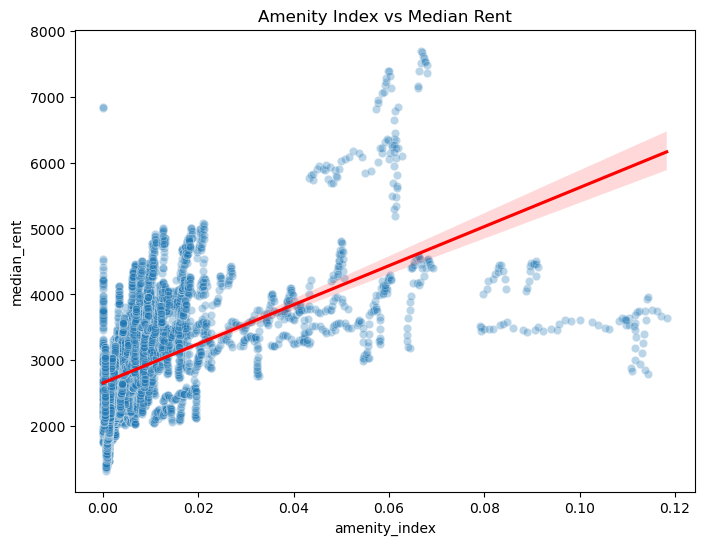

In [66]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="amenity_index", y="median_rent", data=poi_dataset, alpha=0.3)
sns.regplot(x="amenity_index", y="median_rent", data=poi_dataset, scatter=False, color="red")
plt.title("Amenity Index vs Median Rent")
plt.show()

In [74]:
def plot_corr(corr_df):
    plt.figure(figsize=(10,6))
    ax = sns.heatmap(corr_df, annot=False, cmap="coolwarm")

    # Manually add text
    for i in range(len(corr_df)):
        for j in range(len(corr)):
            ax.text(j+0.5, i+0.5, f"{corr.iloc[i,j]:.2f}",
                    ha="center", va="center", color="black", fontsize=10)
            
    plt.show()  

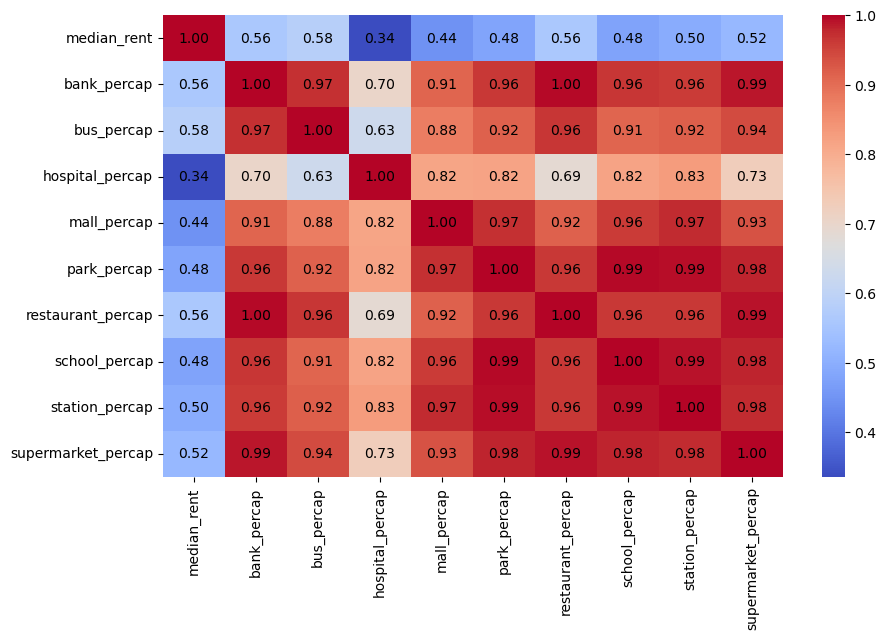

In [ ]:
corr_vars = ["median_rent"] + [c+"_percap" for c in poi_cols]
corr = poi_dataset[corr_vars].corr()
plot_corr(corr)